# 서울 아파트 가격순위 | 2006년 자치구별 실거래 중위가격

처음 실행할 때만 공공데이터포털에서 발급받은 [국토교통부 아파트 매매 실거래가 상세자료 API](https://www.data.go.kr/data/15126468/openapi.do) 인증키로 서울 25개 자치구의 2006년 전체 거래를 수집합니다. 이후에는 저장된 CSV를 우선 사용하므로 국토부 자료를 다시 요청하지 않습니다.

현재 가격을 기준으로 상급지를 정하면 많이 오른 지역이 상급지로 분류되는 사후편향이 발생할 수 있습니다. 따라서 20년 전인 2006년 당시의 국토교통부 실거래가를 이용해 서울 25개 자치구의 가격순위를 먼저 정합니다. 아파트 규모에 따른 영향을 줄이기 위해 거래금액을 전용면적으로 나눈 ㎡당 가격을 사용하고, 일부 고가 거래의 영향을 줄이기 위해 자치구별 중위값을 기준으로 순위를 산출합니다.

저장된 2006년 실거래 CSV 사용: 111,946건


2006년가격순위,자치구,2006년㎡당 가격,20년 연평균상승률,상승률순위
1,강남구,850만 원,4.19%,10
2,서초구,711만 원,4.00%,15
3,송파구,650만 원,4.40%,7
4,용산구,565만 원,4.18%,11
5,광진구,502만 원,4.55%,6
6,성동구,464만 원,4.80%,4
7,중구,463만 원,3.76%,20
8,강동구,459만 원,4.23%,8
9,마포구,447만 원,5.20%,1
10,동작구,426만 원,4.57%,5


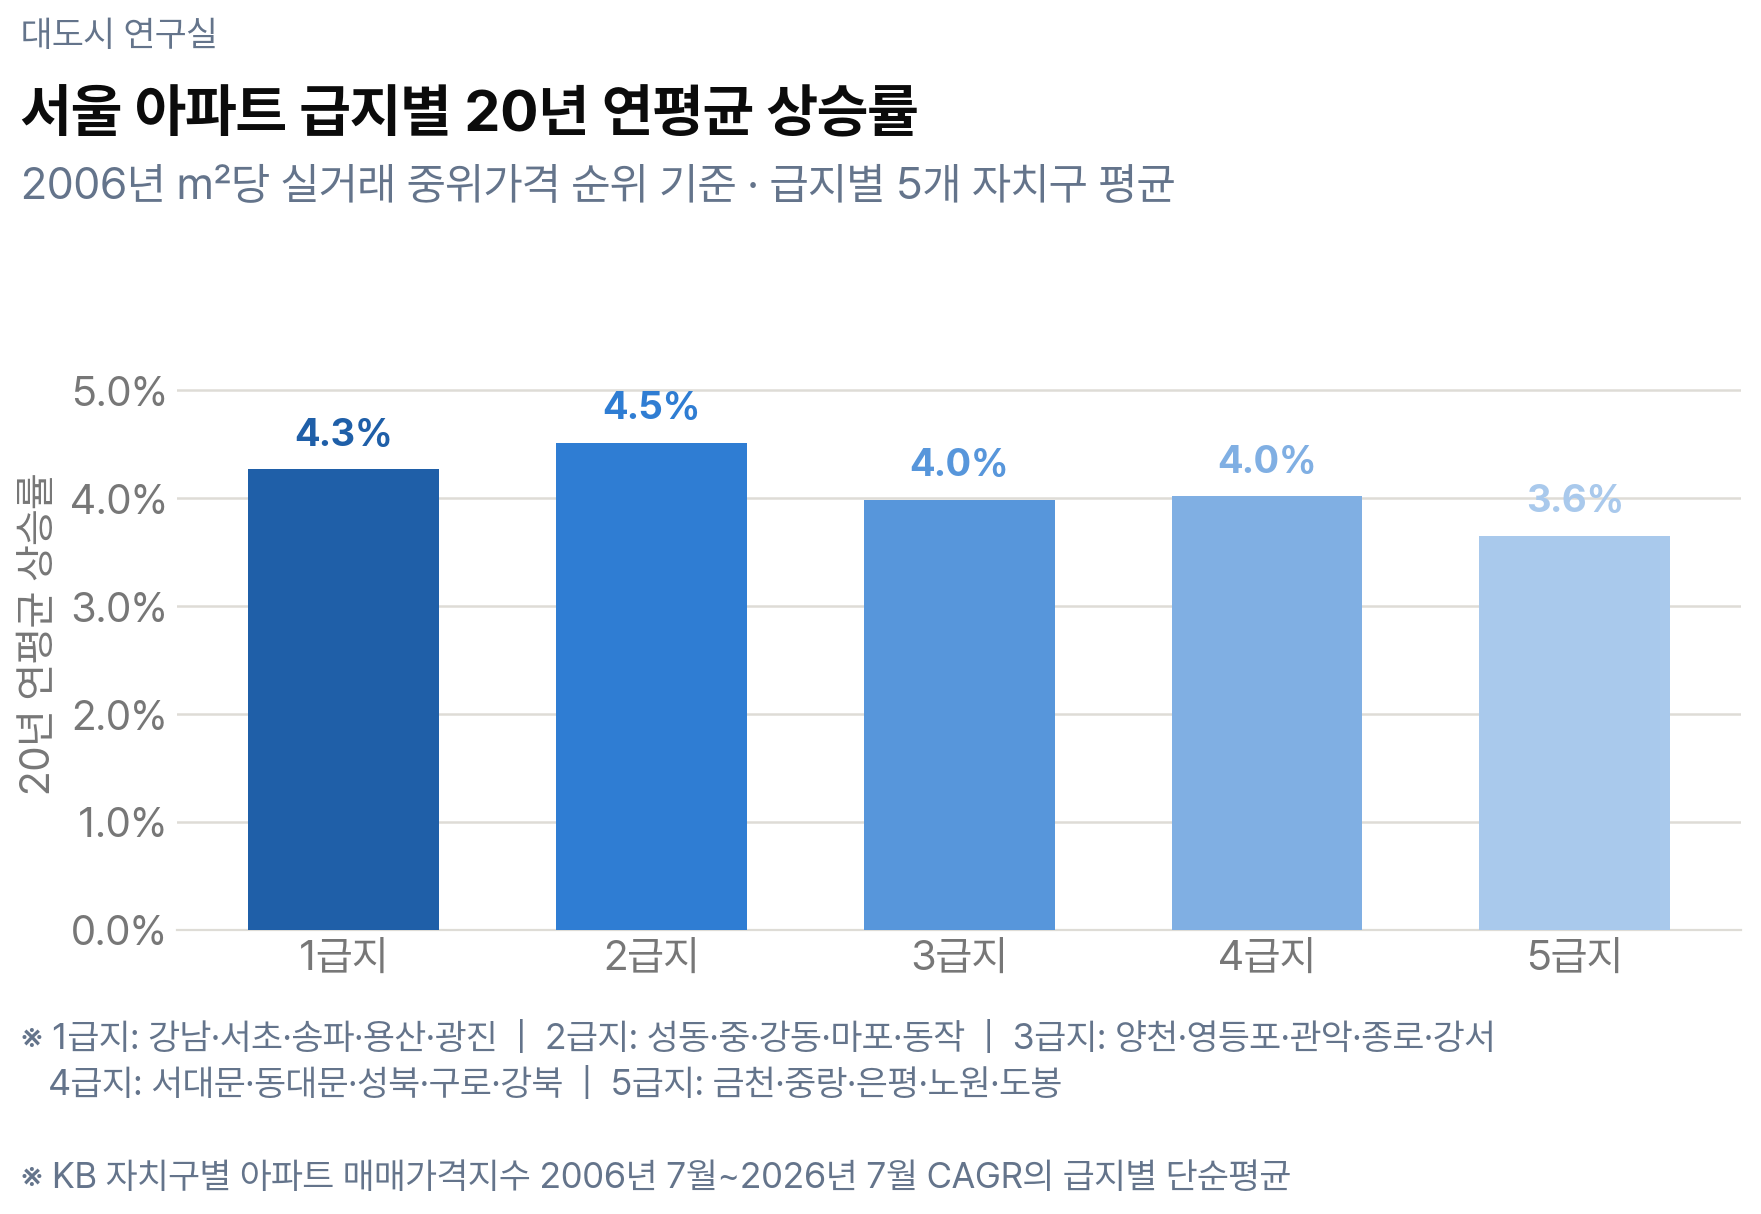

저장된 2016년 실거래 CSV 사용: 110,085건


2016년가격순위,자치구,2016년㎡당 가격,10년 연평균상승률,상승률순위
1,강남구,"1,236만 원",7.56%,7
2,서초구,"1,032만 원",6.76%,11
3,용산구,843만 원,7.53%,8
4,송파구,834만 원,8.42%,1
5,마포구,714만 원,8.00%,2
6,광진구,708만 원,7.60%,6
7,성동구,694만 원,7.85%,4
8,중구,678만 원,5.72%,13
9,동작구,677만 원,7.50%,9
10,종로구,647만 원,4.34%,22


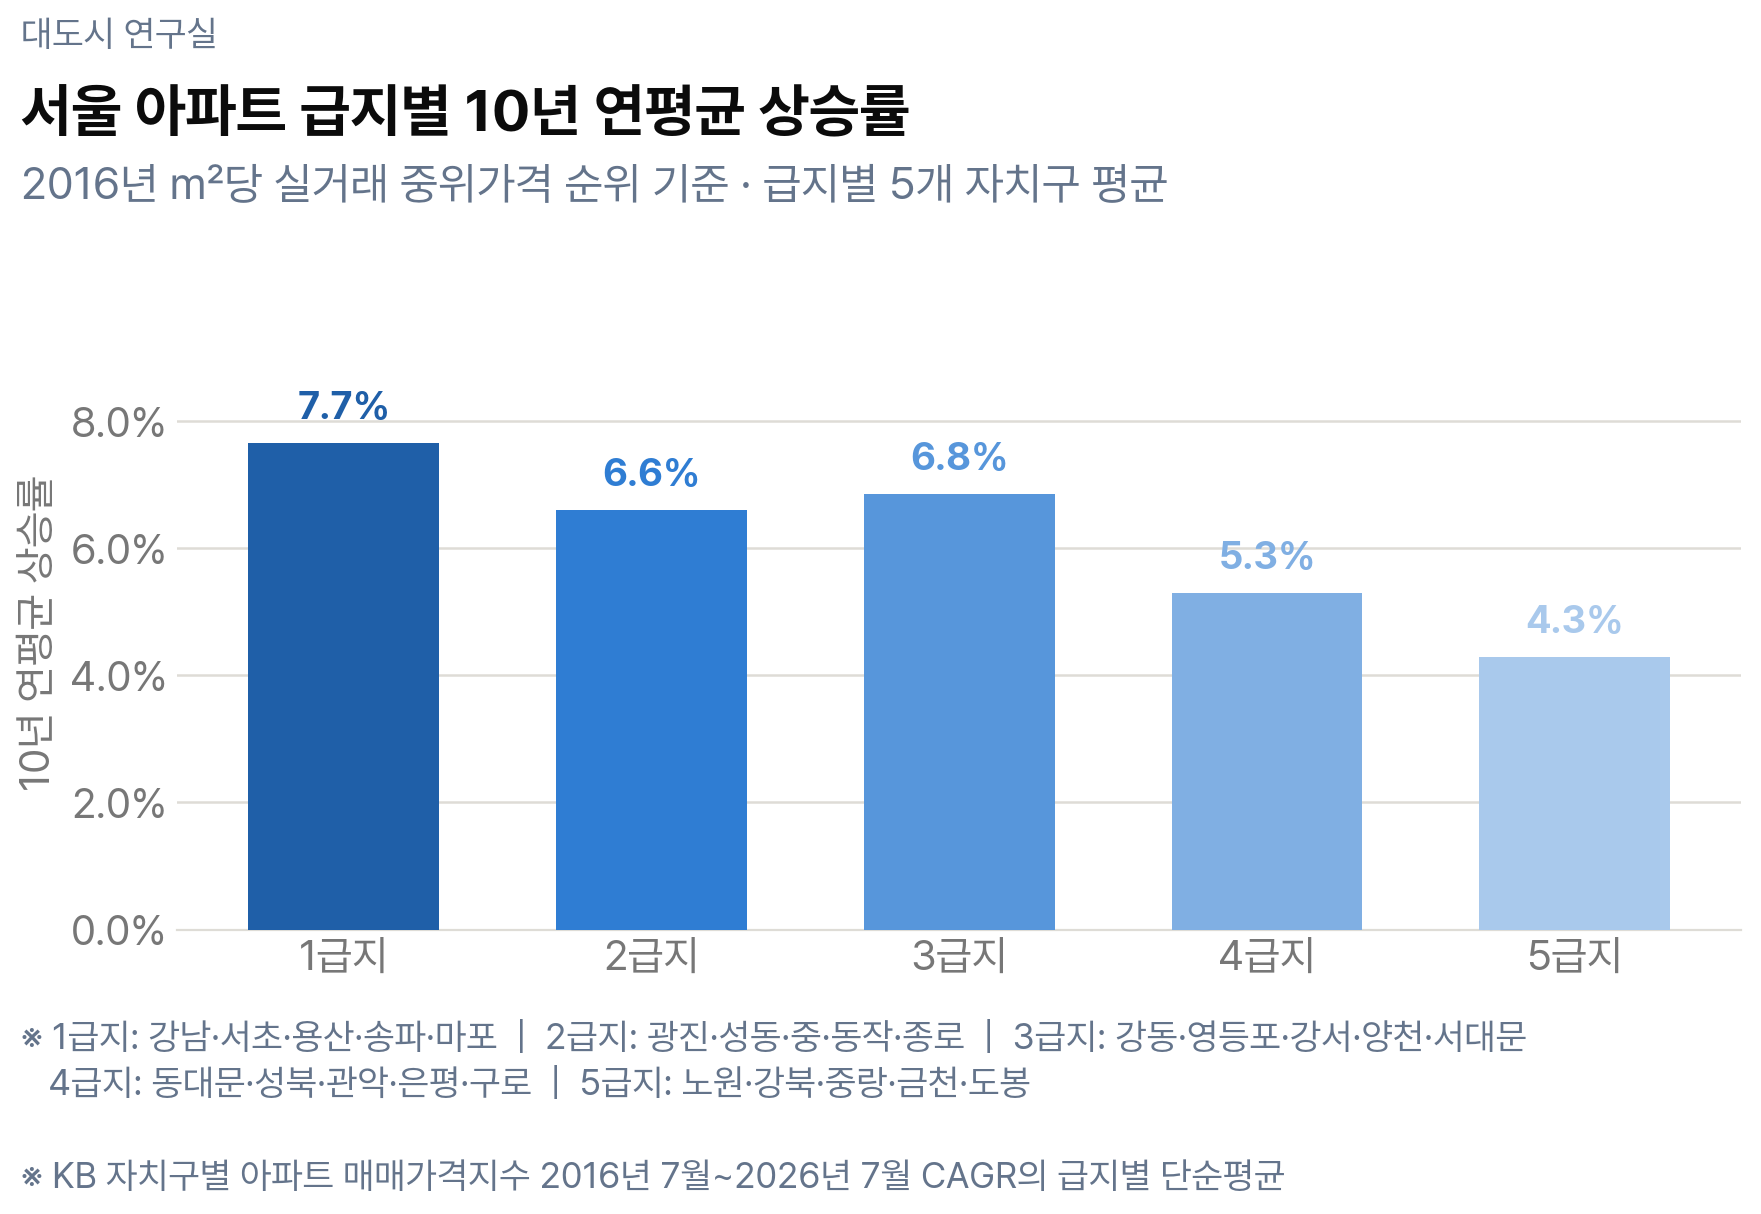

In [1]:
# @title 국토교통부 실거래가 API 인증키를 입력하고 실행하세요
공공데이터_API_인증키 = ""  # @param {type:"string"}

"""2006년 서울 아파트 실거래가격으로 자치구별 가격순위를 산출한다.

국토교통부 아파트 매매 실거래가 상세자료 API에서 서울 25개 자치구의
2006년 1~12월 계약을 수집한다. 각 거래의 거래금액을 전용면적으로 나눈
㎡당 가격을 계산하고, 자치구별 중위값을 기준으로 가격순위를 정한다.
해제 거래와 거래금액·전용면적이 유효하지 않은 행은 제외한다.
"""

from pathlib import Path
import time
from urllib.parse import quote, urlencode
import xml.etree.ElementTree as ET

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import font_manager
import pandas as pd
import requests
from IPython.display import HTML, FileLink, Image, display

IS_COLAB = "google.colab" in __import__("sys").modules
OUTPUT_DIR = Path("/content/output" if IS_COLAB else "output")
ANALYSIS_CONFIGS = (
    (2006, 20, pd.Period("2006-07", freq="M")),
    (2016, 10, pd.Period("2016-07", freq="M")),
)
GROWTH_END_PERIOD = pd.Period("2026-07", freq="M")
MONTHS_PER_YEAR = 12
MANWON_PER_EOK = 10_000
API_URL = (
    "https://apis.data.go.kr/1613000/RTMSDataSvcAptTradeDev/"
    "getRTMSDataSvcAptTradeDev"
)
KB_API_URL = (
    "https://data-api.kbland.kr/bfmstat/weekMnthlyHuseTrnd/"
    "priceIndexOnlyMonthAptExcel"
)
SEOUL_DISTRICTS = {
    "11110": "종로구", "11140": "중구", "11170": "용산구",
    "11200": "성동구", "11215": "광진구", "11230": "동대문구",
    "11260": "중랑구", "11290": "성북구", "11305": "강북구",
    "11320": "도봉구", "11350": "노원구", "11380": "은평구",
    "11410": "서대문구", "11440": "마포구", "11470": "양천구",
    "11500": "강서구", "11530": "구로구", "11545": "금천구",
    "11560": "영등포구", "11590": "동작구", "11620": "관악구",
    "11650": "서초구", "11680": "강남구", "11710": "송파구",
    "11740": "강동구",
}
REQUEST_ROWS = 1_000
REQUEST_TIMEOUT_SECONDS = 30
REQUEST_PAUSE_SECONDS = 0.03

TABLE_HEADER_COLOR = "#2B4A75"
TABLE_TEXT_COLOR = "#1E293B"
TABLE_MUTED_TEXT_COLOR = "#64748B"
TABLE_BORDER_COLOR = "#F0F2F5"
TABLE_STRIPE_COLOR = "#FAFBFC"
BACKGROUND_COLOR = "#FFFFFF"
TEXT_COLOR = "#0B0B0B"
SECONDARY_TEXT_COLOR = "#64748B"
TICK_COLOR = "#777777"
GRID_COLOR = "#DEDCD6"
BAR_COLORS = ("#1F5FA8", "#2F7DD3", "#5796DB", "#80AFE3", "#A9C9EC")
CONTENT_LEFT = 0.025
FONT_CANDIDATES = (
    "Pretendard", "Apple SD Gothic Neo",
    "Noto Sans CJK KR", "Malgun Gothic",
)


def validate_api_key(api_key: str) -> str:
    """입력한 공공데이터포털 인증키를 검증한다."""
    cleaned_key = api_key.strip()
    if not cleaned_key:
        raise ValueError(
            "공공데이터포털에서 발급받은 API 인증키를 입력해주세요."
        )
    return cleaned_key


def build_api_url(api_key: str, district_code: str, deal_month: str, page: int) -> str:
    """인증키의 인코딩 상태를 보존해 API 요청 URL을 만든다."""
    query = urlencode(
        {
            "LAWD_CD": district_code,
            "DEAL_YMD": deal_month,
            "pageNo": page,
            "numOfRows": REQUEST_ROWS,
        }
    )
    return f"{API_URL}?serviceKey={quote(api_key, safe='%')}&{query}"


def read_text(item: ET.Element, *names: str) -> str:
    """API 필드명 변경을 고려해 첫 번째 존재하는 값을 읽는다."""
    for name in names:
        node = item.find(name)
        if node is not None and node.text is not None:
            return node.text.strip()
    return ""


def parse_response(response_text: str) -> tuple[list[dict], int]:
    """실거래가 XML 응답에서 거래 행과 전체 건수를 추출한다."""
    root = ET.fromstring(response_text)
    result_code = root.findtext(".//resultCode", default="").strip()
    result_message = root.findtext(".//resultMsg", default="").strip()
    if result_code not in {"", "00", "000"}:
        raise RuntimeError(f"API 오류 {result_code}: {result_message}")

    total_count_text = root.findtext(".//totalCount", default="0").strip()
    total_count = int(total_count_text or 0)
    rows = []
    for item in root.findall(".//item"):
        rows.append(
            {
                "거래금액_만원": read_text(item, "dealAmount", "거래금액"),
                "전용면적_㎡": read_text(item, "excluUseAr", "전용면적"),
                "계약연도": read_text(item, "dealYear", "년"),
                "계약월": read_text(item, "dealMonth", "월"),
                "계약일": read_text(item, "dealDay", "일"),
                "법정동": read_text(item, "umdNm", "법정동"),
                "아파트": read_text(item, "aptNm", "아파트"),
                "층": read_text(item, "floor", "층"),
                "건축연도": read_text(item, "buildYear", "건축년도"),
                "해제여부": read_text(item, "cdealType", "해제여부"),
            }
        )
    return rows, total_count


def fetch_monthly_trades(
    session: requests.Session,
    api_key: str,
    district_code: str,
    deal_month: str,
) -> list[dict]:
    """한 자치구·계약월의 모든 페이지를 수집한다."""
    all_rows = []
    page = 1
    while True:
        url = build_api_url(api_key, district_code, deal_month, page)
        response = session.get(url, timeout=REQUEST_TIMEOUT_SECONDS)
        response.raise_for_status()
        rows, total_count = parse_response(response.text)
        all_rows.extend(rows)
        if len(all_rows) >= total_count or not rows:
            break
        page += 1
        time.sleep(REQUEST_PAUSE_SECONDS)
    return all_rows


def fetch_seoul_trades(api_key: str, analysis_year: int) -> pd.DataFrame:
    """분석연도 서울 25개 자치구의 아파트 거래를 수집한다."""
    records = []
    request_count = len(SEOUL_DISTRICTS) * MONTHS_PER_YEAR
    completed = 0
    with requests.Session() as session:
        for district_code, district_name in SEOUL_DISTRICTS.items():
            for month in range(1, MONTHS_PER_YEAR + 1):
                deal_month = f"{analysis_year}{month:02d}"
                monthly_rows = fetch_monthly_trades(
                    session, api_key, district_code, deal_month
                )
                for row in monthly_rows:
                    row["자치구코드"] = district_code
                    row["자치구"] = district_name
                    row["계약년월"] = deal_month
                records.extend(monthly_rows)
                completed += 1
                if completed % 25 == 0 or completed == request_count:
                    print(f"자료 수집: {completed}/{request_count}")
                time.sleep(REQUEST_PAUSE_SECONDS)

    if not records:
        raise RuntimeError(
            f"{analysis_year}년 서울 아파트 실거래 자료를 받지 못했습니다. "
            "인증키와 API 활용신청 상태를 확인해주세요."
        )
    return pd.DataFrame(records)


def load_cached_trades(analysis_year: int):
    """저장된 정제 실거래 CSV가 있으면 검증한 뒤 불러온다."""
    cache_path = OUTPUT_DIR / f"seoul_apartment_trades_{analysis_year}.csv"
    if not cache_path.exists():
        return None

    trades = pd.read_csv(cache_path)
    required_columns = {
        "자치구", "거래금액_만원", "전용면적_㎡", "㎡당_실거래가격_만원"
    }
    missing_columns = sorted(required_columns - set(trades.columns))
    if missing_columns:
        raise RuntimeError(
            f"캐시 CSV에 필요한 열이 없습니다: {', '.join(missing_columns)}"
        )
    missing_districts = sorted(
        set(SEOUL_DISTRICTS.values()) - set(trades["자치구"].dropna())
    )
    if missing_districts:
        raise RuntimeError(
            "캐시 CSV에 자료가 없는 자치구가 있습니다: "
            + ", ".join(missing_districts)
        )
    print(f"저장된 {analysis_year}년 실거래 CSV 사용: {len(trades):,}건")
    return trades


def load_or_fetch_trades(api_key: str, analysis_year: int) -> pd.DataFrame:
    """캐시를 우선 사용하고 없을 때만 국토부 자료를 수집·저장한다."""
    cached_trades = load_cached_trades(analysis_year)
    if cached_trades is not None:
        return cached_trades

    validated_key = validate_api_key(api_key)
    raw_trades = fetch_seoul_trades(validated_key, analysis_year)
    cleaned_trades = clean_trades(raw_trades)
    if cleaned_trades.empty:
        raise RuntimeError("유효한 아파트 실거래가 없어 순위를 계산할 수 없습니다.")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    cache_path = OUTPUT_DIR / f"seoul_apartment_trades_{analysis_year}.csv"
    cleaned_trades.to_csv(cache_path, index=False, encoding="utf-8-sig")
    print(
        f"수집 {len(raw_trades):,}건 · 분석 {len(cleaned_trades):,}건 · "
        f"제외 {len(raw_trades) - len(cleaned_trades):,}건"
    )
    print(f"다음 실행부터 사용할 CSV 저장: {cache_path}")
    return cleaned_trades


def clean_trades(raw_trades: pd.DataFrame) -> pd.DataFrame:
    """해제 거래와 계산 불가능한 행을 제외하고 ㎡당 가격을 계산한다."""
    trades = raw_trades.copy()
    trades["거래금액_만원"] = pd.to_numeric(
        trades["거래금액_만원"].str.replace(",", "", regex=False),
        errors="coerce",
    )
    trades["전용면적_㎡"] = pd.to_numeric(
        trades["전용면적_㎡"], errors="coerce"
    )
    valid_cancellation = trades["해제여부"].fillna("").isin(["", "N", "0"])
    valid_amount = trades["거래금액_만원"] > 0
    valid_area = trades["전용면적_㎡"] > 0
    trades = trades.loc[valid_cancellation & valid_amount & valid_area].copy()
    trades["㎡당_실거래가격_만원"] = (
        trades["거래금액_만원"] / trades["전용면적_㎡"]
    )
    return trades


def download_district_growth(
    start_period: pd.Period, growth_years: int
) -> pd.DataFrame:
    """KB 자치구별 지수로 지정 기간의 CAGR을 계산한다."""
    params = {
        "매매전세코드": "01",
        "월간주간구분코드": "01",
        "매물종별구분": "01",
        "지역코드": "",
        "type": "false",
    }
    response = requests.get(
        KB_API_URL,
        params=params,
        headers={
            "osType": "HUB",
            "User-Agent": "Mozilla/5.0",
            "Referer": "https://data.kbland.kr/",
        },
        timeout=REQUEST_TIMEOUT_SECONDS,
    )
    response.raise_for_status()
    payload = response.json()
    header = payload.get("dataHeader", {})
    if header.get("resultCode") != "10000":
        raise RuntimeError(
            "KB 가격지수를 받지 못했습니다: "
            + header.get("message", "알 수 없는 오류")
        )

    district_codes = {f"{code}00000": name for code, name in SEOUL_DISTRICTS.items()}
    rows = []
    data_rows = payload["dataBody"]["data"]["데이터리스트"]
    for district in data_rows:
        district_code = district.get("지역코드")
        if district_code not in district_codes:
            continue
        index_by_period = {
            pd.Period(item["기준날짜"], freq="M"): float(item["데이터"])
            for item in district["dataList"]
            if item.get("데이터") is not None
        }
        if start_period not in index_by_period:
            raise RuntimeError(
                f"{district_codes[district_code]}의 {start_period} 지수가 없습니다."
            )
        if GROWTH_END_PERIOD not in index_by_period:
            raise RuntimeError(
                f"{district_codes[district_code]}의 {GROWTH_END_PERIOD} 지수가 없습니다."
            )
        start_index = index_by_period[start_period]
        end_index = index_by_period[GROWTH_END_PERIOD]
        cagr = (end_index / start_index) ** (1 / growth_years) - 1
        rows.append({"자치구": district_codes[district_code], "기간_CAGR": cagr})

    growth = pd.DataFrame(rows)
    if len(growth) != len(SEOUL_DISTRICTS):
        raise RuntimeError("KB 가격지수에서 서울 25개 자치구를 찾지 못했습니다.")
    growth["상승률순위"] = (
        growth["기간_CAGR"].rank(method="min", ascending=False).astype(int)
    )
    return growth


def calculate_district_ranking(
    trades: pd.DataFrame, district_growth: pd.DataFrame, analysis_year: int
) -> pd.DataFrame:
    """분석연도 가격순위에 이후 CAGR과 상승률 순위를 결합한다."""
    ranking = (
        trades.groupby("자치구", as_index=False)
        .agg(
            **{
                "거래건수": ("㎡당_실거래가격_만원", "size"),
                "중위가격_만원_㎡": ("㎡당_실거래가격_만원", "median"),
            }
        )
        .sort_values("중위가격_만원_㎡", ascending=False)
        .reset_index(drop=True)
    )
    ranking.insert(0, "가격순위", range(1, len(ranking) + 1))
    ranking = ranking.merge(
        district_growth, on="자치구", how="left", validate="one_to_one"
    )

    missing_districts = sorted(set(SEOUL_DISTRICTS.values()) - set(ranking["자치구"]))
    if missing_districts:
        raise RuntimeError(
            "거래 자료가 없는 자치구가 있습니다: " + ", ".join(missing_districts)
        )
    if len(ranking) != len(SEOUL_DISTRICTS):
        raise RuntimeError("서울 25개 자치구 순위가 완성되지 않았습니다.")
    if ranking[["기간_CAGR", "상승률순위"]].isna().any().any():
        raise RuntimeError(f"일부 자치구의 {analysis_year}년 이후 상승률이 없습니다.")
    return ranking


def format_median_price(value: float) -> str:
    """㎡당 중위가격을 만원 단위 정수로 표시한다."""
    return f"{value:,.0f}만 원"


def calculate_tier_growth(ranking: pd.DataFrame) -> pd.DataFrame:
    """가격순위를 5개 구씩 묶어 급지별 평균 CAGR을 계산한다."""
    tier_growth = ranking.copy()
    tier_growth["급지번호"] = (tier_growth["가격순위"] - 1) // 5 + 1
    summary = (
        tier_growth.groupby("급지번호", as_index=False)
        .agg(
            평균_CAGR=("기간_CAGR", "mean"),
            자치구=("자치구", lambda values: "·".join(values)),
        )
        .sort_values("급지번호")
    )
    summary["급지"] = summary["급지번호"].map(lambda value: f"{value}급지")
    return summary


def configure_korean_font() -> None:
    """사용 가능한 한글 글꼴을 Matplotlib에 설정한다."""
    installed = {font.name for font in font_manager.fontManager.ttflist}
    font_name = next((name for name in FONT_CANDIDATES if name in installed), None)
    if font_name:
        plt.rcParams["font.family"] = font_name
    plt.rcParams["axes.unicode_minus"] = False


def save_tier_growth_chart(
    tier_growth: pd.DataFrame, analysis_year: int, growth_years: int,
    start_period: pd.Period, output_path: Path,
) -> None:
    """급지별 지정 기간 평균 CAGR 막대그래프를 저장한다."""
    configure_korean_font()
    fig, ax = plt.subplots(figsize=(9.2, 6.6))
    fig.patch.set_facecolor(BACKGROUND_COLOR)
    ax.set_facecolor(BACKGROUND_COLOR)
    fig.subplots_adjust(left=0.11, right=0.96, top=0.72, bottom=0.27)

    bars = ax.bar(
        tier_growth["급지"],
        tier_growth["평균_CAGR"],
        color=BAR_COLORS,
        width=0.62,
        zorder=3,
    )
    y_max = max(float(tier_growth["평균_CAGR"].max()) * 1.22, 0.01)
    ax.set_ylim(0, y_max)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=1))
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.9, zorder=0)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.tick_params(axis="both", colors=TICK_COLOR, labelsize=15, length=0)
    ax.set_ylabel(f"{growth_years}년 연평균 상승률", fontsize=15, color=TICK_COLOR)

    for bar, value in zip(bars, tier_growth["평균_CAGR"]):
        ax.annotate(
            f"{value:.1%}",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=14,
            fontweight="bold",
            color=bar.get_facecolor(),
        )

    fig.text(
        CONTENT_LEFT, 0.94, "대도시 연구실", ha="left",
        fontsize=13, color=SECONDARY_TEXT_COLOR,
    )
    fig.text(
        CONTENT_LEFT, 0.875,
        f"서울 아파트 급지별 {growth_years}년 연평균 상승률",
        ha="left", fontsize=21, fontweight="bold", color=TEXT_COLOR,
    )
    fig.text(
        CONTENT_LEFT, 0.825,
        f"{analysis_year}년 ㎡당 실거래 중위가격 순위 기준 · 급지별 5개 자치구 평균",
        ha="left", fontsize=16, color=SECONDARY_TEXT_COLOR,
    )
    tier_lines = [
        f"{row.급지}: {row.자치구.replace('구·', '·').removesuffix('구')}"
        for row in tier_growth.itertuples(index=False)
    ]
    tier_note = (
        "※ " + "  |  ".join(tier_lines[:3]) + "\n   "
        + "  |  ".join(tier_lines[3:])
    )
    fig.text(
        CONTENT_LEFT, 0.145, tier_note, ha="left",
        fontsize=13, color=SECONDARY_TEXT_COLOR, linespacing=1.45,
    )
    fig.text(
        CONTENT_LEFT, 0.075,
        f"※ KB 자치구별 아파트 매매가격지수 {start_period.year}년 "
        f"{start_period.month}월~{GROWTH_END_PERIOD.year}년 "
        f"{GROWTH_END_PERIOD.month}월 CAGR의 급지별 단순평균",
        ha="left", fontsize=13, color=SECONDARY_TEXT_COLOR,
    )
    fig.savefig(
        output_path, dpi=200, bbox_inches="tight", facecolor=BACKGROUND_COLOR
    )
    plt.close(fig)


def build_ranking_table_html(
    ranking: pd.DataFrame, analysis_year: int, growth_years: int,
    start_period: pd.Period,
) -> str:
    """스타일 가이드에 맞춘 자치구 가격순위 HTML 표를 만든다."""
    rows = []
    for _, row in ranking.iterrows():
        rows.append(
            "<tr>"
            f"<td class='identifier'>{int(row['가격순위'])}</td>"
            f"<td class='identifier district'>{row['자치구']}</td>"
            f"<td class='number'>{format_median_price(row['중위가격_만원_㎡'])}</td>"
            f"<td class='number'>{row['기간_CAGR']:.2%}</td>"
            f"<td class='identifier'>{int(row['상승률순위'])}</td>"
            "</tr>"
        )

    return f"""
<style>
.seoul-tier-table {{
    max-width: 700px; margin: 12px 0 28px;
    font-family: Pretendard, -apple-system, BlinkMacSystemFont,
        'Segoe UI', sans-serif;
}}
.seoul-tier-table .table-header {{ margin: 0 0 14px; }}
.seoul-tier-table .table-brand {{
    margin: 0 0 5px; color: {TABLE_MUTED_TEXT_COLOR}; font-size: 13px;
    font-weight: 400;
}}
.seoul-tier-table .table-title {{
    margin: 0 0 5px; color: #0B0B0B; font-size: 21px;
    line-height: 1.3; font-weight: 700;
}}
.seoul-tier-table .table-caption {{
    margin: 0; color: {TABLE_MUTED_TEXT_COLOR}; font-size: 16px;
    line-height: 1.4; font-weight: 400;
}}
.seoul-tier-table .table-wrap {{
    overflow-x: auto; border: 1px solid {TABLE_BORDER_COLOR};
    border-radius: 12px;
}}
.seoul-tier-table table {{
    width: 100%; table-layout: fixed; border-collapse: separate;
    border-spacing: 0; color: {TABLE_TEXT_COLOR}; font-size: 13px;
    font-variant-numeric: tabular-nums;
}}
.seoul-tier-table th {{
    padding: 8px 12px; background: {TABLE_HEADER_COLOR}; color: white;
    border-bottom: 2px solid #7FB3D5; font-weight: 700;
    text-align: center; white-space: nowrap;
}}
.seoul-tier-table td {{
    padding: 7px 12px; border-bottom: 1px solid {TABLE_BORDER_COLOR};
    background: white; text-align: center; white-space: nowrap;
}}
.seoul-tier-table tbody tr:nth-child(even) td {{
    background: {TABLE_STRIPE_COLOR};
}}
.seoul-tier-table tbody tr:hover td {{ background: #EFF6FF; }}
.seoul-tier-table tbody tr:last-child td {{ border-bottom: 0; }}
.seoul-tier-table .identifier {{ text-align: center; }}
.seoul-tier-table .district {{ font-weight: 600; }}
.seoul-tier-table .number {{ text-align: right; }}
.seoul-tier-table .table-footnote {{
    margin: 10px 0 0; color: {TABLE_MUTED_TEXT_COLOR};
    font-size: 13px; line-height: 1.5;
}}
</style>
<section class="seoul-tier-table">
  <div class="table-header">
    <p class="table-brand">대도시 연구실</p>
    <h2 class="table-title">서울 25개 자치구의 {analysis_year}년 가격순위와 이후 {growth_years}년 상승률 비교</h2>
    <p class="table-caption">{analysis_year}년 전체 실거래 · KB 아파트 매매가격지수 {start_period.year}.{start_period.month}~{GROWTH_END_PERIOD.year}.{GROWTH_END_PERIOD.month}</p>
  </div>
  <div class="table-wrap">
    <table>
      <colgroup><col style="width:17%"><col style="width:16%"><col style="width:24%"><col style="width:27%"><col style="width:16%"></colgroup>
      <thead><tr><th>{analysis_year}년<br>가격순위</th><th>자치구</th><th>{analysis_year}년<br>㎡당 가격</th><th>{growth_years}년 연평균<br>상승률</th><th>상승률<br>순위</th></tr></thead>
      <tbody>{''.join(rows)}</tbody>
    </table>
  </div>
  <p class="table-footnote">
    ※ 거래금액을 전용면적으로 나눈 각 거래의 ㎡당 가격을 자치구별로 집계한 중위값이다.<br>
    ※ {growth_years}년 연평균 상승률은 KB 자치구별 아파트 매매가격지수의 {start_period.year}년 {start_period.month}월~{GROWTH_END_PERIOD.year}년 {GROWTH_END_PERIOD.month}월 CAGR이다.
  </p>
</section>
"""


def save_results(
    ranking: pd.DataFrame, tier_growth: pd.DataFrame, analysis_year: int,
    growth_years: int, start_period: pd.Period,
) -> tuple[Path, Path, Path]:
    """실거래 캐시, 순위 CSV와 급지별 상승률 그래프를 저장한다."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    detail_path = OUTPUT_DIR / f"seoul_apartment_trades_{analysis_year}.csv"
    ranking_path = OUTPUT_DIR / f"seoul_apartment_district_ranking_{analysis_year}.csv"
    chart_path = OUTPUT_DIR / f"seoul_apartment_tier_{growth_years}y_cagr.png"
    ranking.to_csv(ranking_path, index=False, encoding="utf-8-sig")
    save_tier_growth_chart(
        tier_growth, analysis_year, growth_years, start_period, chart_path
    )
    return detail_path, ranking_path, chart_path


def display_download_links(
    detail_path: Path, ranking_path: Path, chart_path: Path
) -> None:
    """Colab에서는 다운로드 버튼, 로컬에서는 파일 링크를 표시한다."""
    try:
        import ipywidgets as widgets
        from google.colab import files

        for label, path in (
            ("정제 실거래자료 CSV", detail_path),
            ("자치구 가격순위 CSV", ranking_path),
            ("급지별 상승률 그래프", chart_path),
        ):
            button = widgets.Button(description=f"{label} 다운로드", icon="download")
            button.on_click(lambda _, target=path: files.download(str(target)))
            display(button)
    except ImportError:
        display(
            FileLink(str(detail_path)), FileLink(str(ranking_path)),
            FileLink(str(chart_path)),
        )


def run_analysis(
    api_key: str, analysis_year: int, growth_years: int,
    start_period: pd.Period,
) -> pd.DataFrame:
    """한 기준연도의 자료 수집부터 표·그래프 출력까지 실행한다."""
    cleaned_trades = load_or_fetch_trades(api_key, analysis_year)
    district_growth = download_district_growth(start_period, growth_years)
    ranking = calculate_district_ranking(
        cleaned_trades, district_growth, analysis_year
    )
    tier_growth = calculate_tier_growth(ranking)
    detail_path, ranking_path, chart_path = save_results(
        ranking, tier_growth, analysis_year, growth_years, start_period
    )
    display(HTML(build_ranking_table_html(
        ranking, analysis_year, growth_years, start_period
    )))
    display(Image(filename=str(chart_path)))
    display_download_links(detail_path, ranking_path, chart_path)
    return ranking




def main(api_key: str) -> dict[int, pd.DataFrame]:
    """2006년·2016년 가격순위와 이후 상승률을 차례로 분석한다."""
    results = {}
    for analysis_year, growth_years, start_period in ANALYSIS_CONFIGS:
        results[analysis_year] = run_analysis(
            api_key, analysis_year, growth_years, start_period
        )
    return results


district_rankings = main(공공데이터_API_인증키)
